In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
url = "https://socialblade.com/instagram/user/bopomofocafe"
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://google.com"
}
cookies = {
    "session": "f63fdcbbc0dc8434698aee8a7d4c3c11316af0e23e1cb2f38ef4ea0498542eb8"
}

response = requests.get(url, headers=headers, cookies=cookies)


if response.status_code == 200:
    print("Success")
else:
    print(response.status_code)
    print(response.text[:500])
#soup = BeautifulSoup(response.content, 'html.parser')

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

# Setup Selenium
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# Go to page
url = "https://socialblade.com/instagram/user/bopomofocafe"
driver.get(url)

# Wait for content to load
time.sleep(5)

html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

# Debug: print part of the HTML to confirm you’re seeing the real page
print(html[:500])

# --- Find the Daily Channel Metrics table ---
# Inspect the page and see the table has id "socialblade-user-content"
table = soup.find("div", id="socialblade-user-content")

if table:
    # Usually the table is in <table> tags
    table_rows = table.find_all("tr")
    for row in table_rows:
        cols = row.find_all(["td", "th"])
        cols_text = [c.get_text(strip=True) for c in cols]
        if cols_text:
            print(cols_text)
else:
    print("Could not find the Daily Channel Metrics table.")

driver.quit()


In [ ]:
import requests
import json
import csv

# --- API URL ---
url = "https://socialblade.com/api/trpc/instagram.user?batch=1&input=%7B%220%22%3A%7B%22json%22%3A%7B%22id%22%3A%22bopomofocafe%22%7D%7D%7D"

# --- Set headers (optional but helps avoid blocking) ---
headers = {
    "User-Agent": "Mozilla/5.0"
}

# --- Fetch JSON data ---
response = requests.get(url, headers=headers)
data = response.json()

# --- Navigate JSON to Daily Channel Metrics ---
try:
    daily_metrics = data["result"]["0"]["json"]["daily_metrics"]
except KeyError:
    print("Could not find 'daily_metrics' in JSON")
    daily_metrics = []

if not daily_metrics:
    print("No daily metrics found.")
    exit()

# --- Extract headers and rows ---
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

# --- Save to CSV ---
csv_file = "daily_channel_metrics.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)  # header row
    writer.writerows(rows)        # data rows

print(f"Saved {len(rows)} rows to {csv_file}")


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import json
import csv
import time


# --- Setup Selenium ---
options = Options()
# Keep headless OFF for manual login
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# --- Step 1: Open login page ---
login_url = "https://socialblade.com/login"
driver.get(login_url)

print("Please log in manually in the opened browser window.")
print("After logging in, press Enter here to continue...")
input()  # Pause the script until user presses Enter

# --- Step 2: Access API URL after login ---
api_url = "https://socialblade.com/api/trpc/instagram.user?batch=1&input=%7B%220%22%3A%7B%22json%22%3A%7B%22id%22%3A%22bopomofocafe%22%7D%7D%7D"
driver.get(api_url)

# Wait a few seconds for JSON to load
time.sleep(5)

# JSON usually appears inside <pre>
try:
    pre_element = driver.find_element("tag name", "pre")
    raw_json = pre_element.text
    data = json.loads(raw_json)
except Exception as e:
    print("Error fetching or parsing JSON:", e)
    driver.quit()
    exit()

# Close the browser
driver.quit()

# --- Step 3: Extract Daily Channel Metrics ---
try:
    daily_metrics = data["result"]["0"]["json"]["daily_metrics"]
except KeyError:
    print("Could not find 'daily_metrics' in JSON")
    daily_metrics = []

if not daily_metrics:
    print("No daily metrics found.")
    exit()

# --- Step 4: Save to CSV ---
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

csv_file = "daily_channel_metrics.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {csv_file}")


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import json
import pandas as pd
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://socialblade.com/instagram/user/bopomofocafe")

html = driver.page_source
driver.quit()

# Extract the NEXT_DATA JSON
start = html.find("__NEXT_DATA__")
json_start = html.find("{", start)
json_end = html.find("</script>", json_start)
json_str = html[json_start:json_end]
data = json.loads(json_str)



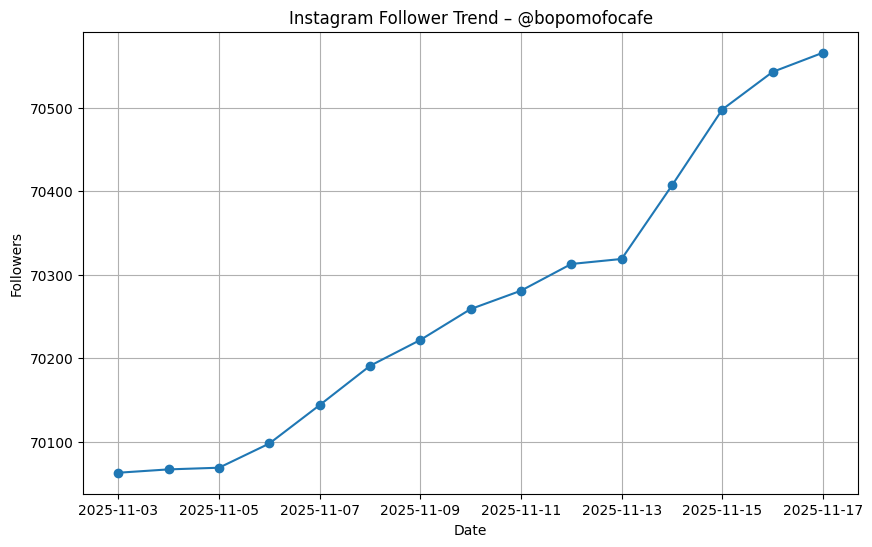

In [2]:
queries = []
if "trpcState" in data:
    queries = data["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"] and "trpcState" in data["props"]["pageProps"]:
    queries = data["props"]["pageProps"]["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"]:
    # fallback scan entire object for queries
    for v in data["props"]["pageProps"].values():
        if isinstance(v, dict) and "queries" in v:
            queries = v["queries"]

history_block = None
for q in queries:
    if q["queryKey"][0] == ["instagram", "history"]:
        history_block = q
        break

if history_block is None:
    raise Exception("Could not find the Instagram history block.")

# Extract the daily stats
days = history_block["state"]["data"]

# Build DataFrame
df = pd.DataFrame(days)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Plot
plt.figure(figsize=(10,6))
plt.plot(df["date"], df["followers"], marker="o")
plt.title("Instagram Follower Trend – @bopomofocafe")
plt.xlabel("Date")
plt.ylabel("Followers")
plt.grid(True)
plt.show()